In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft

In [ ]:
t=np.linspace(0,np.pi*3,400)
a_1,a_2=0.3,0.1
source=a_1*np.sin(0.5*np.pi*t)+0.4
noise=a_2*(np.random.rand(1,400)[0]-0.5)
signal=(source+noise)*np.sin(2*np.pi*t)*np.sin(2*np.pi*t+0.2*np.pi)
#np.sin(2*np.pi*t+0.2*np.pi)*np.sin(2*np.pi*t)
plt.figure(dpi=120)
plt.plot(t,signal,label="signal")
plt.xlabel('t(s)')
plt.ylabel('x(t)')
plt.legend()
plt.show()

In [ ]:
xf=np.linspace(0,3,100)
yf=fft(signal)

plt.plot(xf,0.01*abs(yf[0:100]))
plt.show()

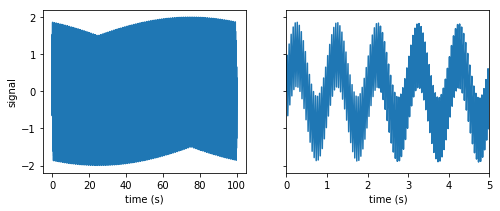

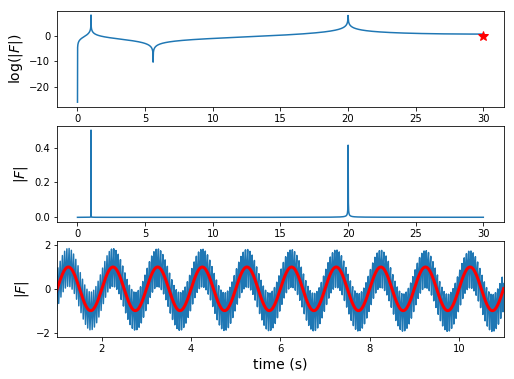

In [4]:
def signal_samples(t):
    return np.sin(2 * np.pi * 1 * t)  + np.sin(2 * np.pi * 20 *t)

B = 30.0
f_s = 2 * B
delta_f = 0.01
N = int(f_s / delta_f)
T = N / f_s
t = np.linspace(0, T, N)

f_t = signal_samples(t)
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
axes[0].plot(t, f_t)
axes[0].set_xlabel("time (s)")
axes[0].set_ylabel("signal")
axes[1].plot(t, f_t)
axes[1].set_xlim(0, 5)
axes[1].set_xlabel("time (s)")
plt.show()

from scipy import fftpack
F = fftpack.fft(f_t)
f = fftpack.fftfreq(N, 1.0/f_s)
F_filtered = F * (abs(f) < 10)
f_t_filtered = fftpack.ifft(F_filtered)
mask = np.where(f >= 0)

fig, axes = plt.subplots(3, 1, figsize=(8, 6))
axes[0].plot(f[mask], np.log(abs(F[mask])), label="real")
axes[0].plot(B, 0, 'r*', markersize=10)
axes[0].set_ylabel("$\log(|F|)$", fontsize=14)
axes[1].plot(f[mask], abs(F[mask])/N, label="real")

axes[1].set_ylabel("$|F|$", fontsize=14)
axes[2].plot(t, f_t, label='original')
axes[2].plot(t, f_t_filtered.real, color="red", lw = 3, label='filtered')
axes[2].set_xlim(1, 11)
axes[2].set_xlabel("time (s)", fontsize=14)
axes[2].set_ylabel("$|F|$", fontsize=14)
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fftfreq,fft,ifft
#原始信号
def signal(t):
    return np.sin(2*np.pi*8*t)+1.2*np.sin(2*np.pi*20*t)
t=np.linspace(0,100,6000)
f_t=signal(t)+2.5*np.random.rand(1,6000)[0]
#作傅里叶变换，得到频率谱
F=fft(f_t)
f=fftfreq(6000,1/60)
#把1Hz的信号滤去
F_filtered=F*(abs(f)<10)
f_t_filtered=ifft(F_filtered)
mask = np.where(f >= 0)

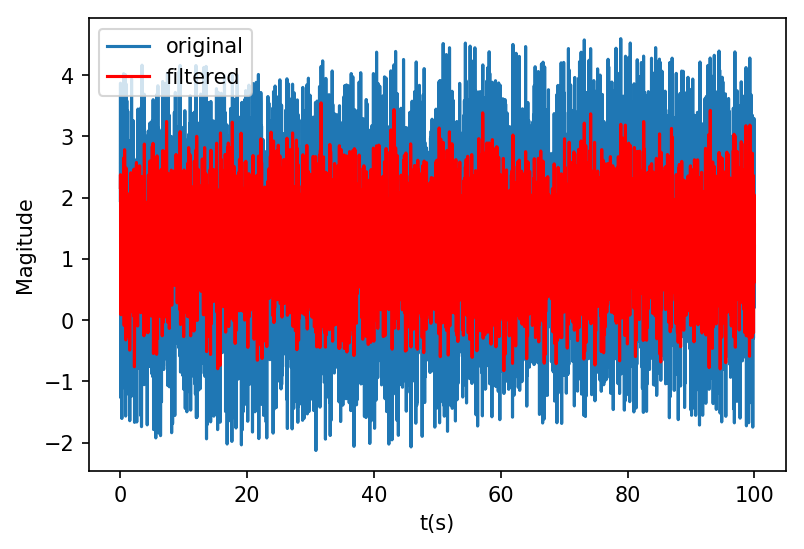

In [2]:
plt.figure(dpi=150)
plt.xlabel('t(s)')
plt.ylabel('Magitude')
plt.plot(t,f_t,label="original")
plt.plot(t,f_t_filtered.real,color='red',label="filtered")
plt.legend()
#plt.savefig('GH.jpg')
plt.show()

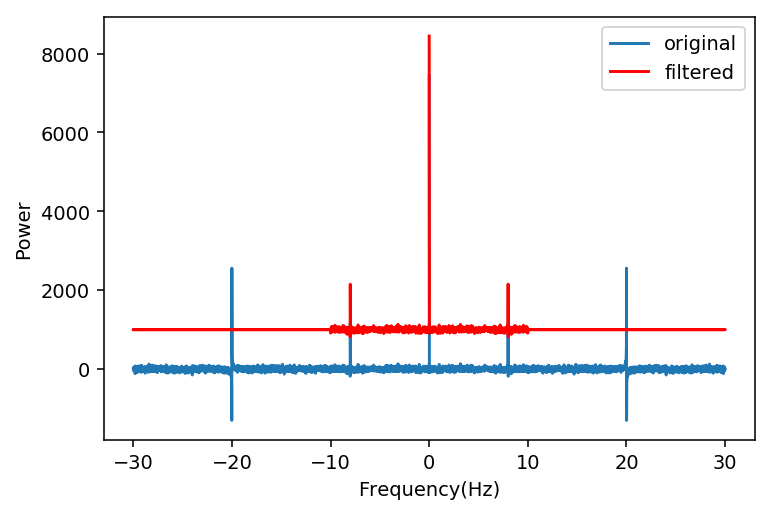

In [3]:
F_g=fft(f_t_filtered)
plt.figure(dpi=140)
plt.xlabel('Frequency(Hz)')
plt.ylabel('Power')
plt.plot(f,F.real,label="original")
plt.plot(f,F_g.real+1000,color='red',label="filtered")
plt.legend()
#plt.savefig('GH2.jpg')

In [ ]:
y=f_t-f_t_filtered.real
y